In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import parcels

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_30319/1848085155.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
df = [parcels.read_particlefile(f"../Simulations/Simulation_Satellite_kN_{k_N}.parquet") for k_N in [0.01, 0.001, 0.000129]]

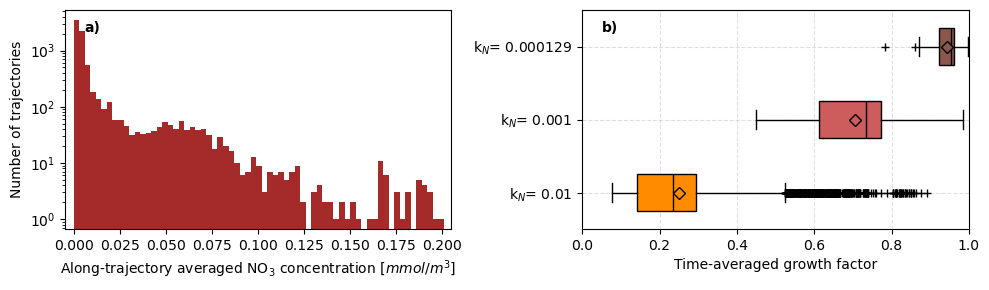

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

colors = ['darkorange', 'indianred', 'tab:brown']
names = ['k$_N$= 0.01', 'k$_N$= 0.001', 'k$_N$= 0.000129']

for i, dframe in enumerate(df):
    last_time = dframe.select(pl.col("time").max()).item()
    df_reaching_last_time = dframe.filter(
        (pl.col("time").max().over("particle_id") == last_time) &
        (pl.col("stranded").last().over("particle_id") == False)
    )

    if i == 1:
        data = (
            df_reaching_last_time
            .group_by("particle_id")
            .agg(pl.col('nitrogen').drop_nans().mean().alias('nitrogen'))
            .get_column('nitrogen')
            .to_numpy()
        )

        ax[0].hist(data[~np.isnan(data)], bins=100, range=(0, 0.3), log=True, color='brown')
        ax[0].set_xlabel('Along-trajectory averaged NO$_3$ concentration [$mmol / m^3$]')
        ax[0].set_ylabel('Number of trajectories')
        ax[0].set_xlim(-0.005, 0.205)

    data = (
        df_reaching_last_time
        .group_by("particle_id")
        .agg(pl.col('lim_nitrogen').drop_nans().mean().alias('lim_nitrogen'))
        .get_column('lim_nitrogen')
        .to_numpy()
    )

    ax[1].boxplot(
        data[~np.isnan(data)],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+'
    )

for i, name in enumerate(names):
    ax[1].plot([], [], color=colors[i], label=name)
ax[1].set_yticks(range(len(names)))
ax[1].set_yticklabels(names)
ax[1].set_xlabel('Time-averaged growth factor')
ax[1].set_xlim(0,1)
ax[1].grid( linestyle='--', alpha=0.4)

for i, label in enumerate(['a)', 'b)']):
    ax[i].text(0.05, 0.95, label, transform=ax[i].transAxes,
               fontsize=10, fontweight='bold', va='top')

plt.tight_layout()
fig.savefig('Figures/Figure3.pdf', bbox_inches='tight', dpi=300)
plt.show()